# Analisis de convergencia sin presion (grosor, no error)

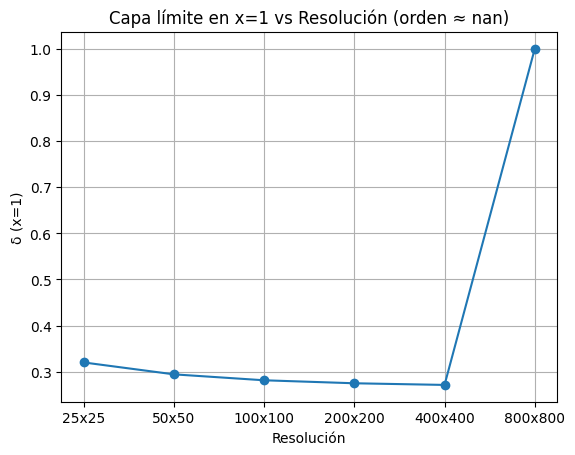

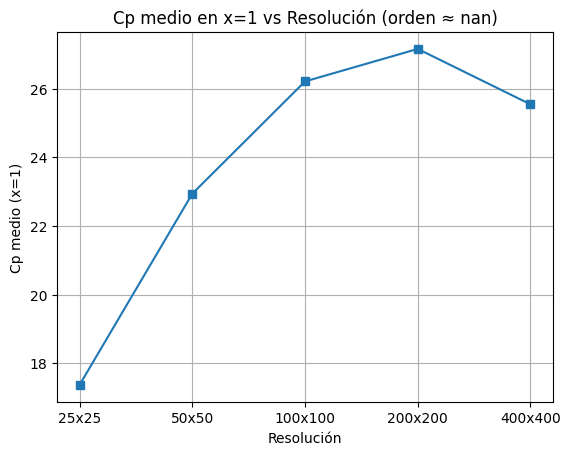

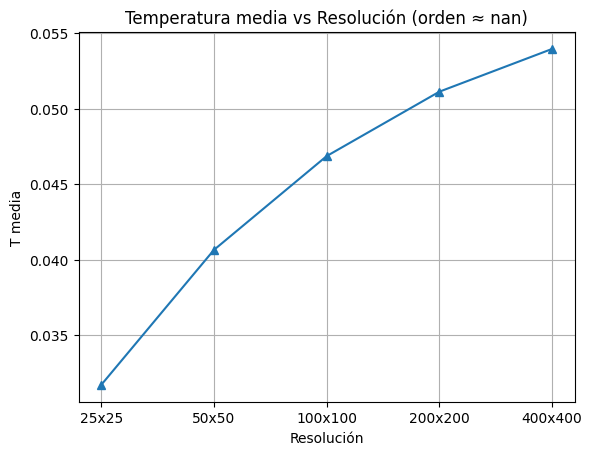

In [5]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ADAPTADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9):
    """
    Interpola la altura en x=1 donde la magnitud de la velocidad cruza vel_level.
    """
    x_index = np.argmin(np.abs(X_star[0] - 1.0))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)

    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return y[-1]  # no se cruzó

def calcular_coeficiente_presion_derecha(p, X_star):
    j = np.argmin(np.abs(X_star[-1] - 1.0))
    return np.mean(p[:, j])

def calcular_temperatura_media(T):
    return np.mean(T)

def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- GRÁFICAS ---
def representar_convergencia(res_labels, delta_vals, cp_vals, Tavg_vals):
    r = 2
    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_cp = orden_convergencia(cp_vals[-3], cp_vals[-2], cp_vals[-1], r)
        p_T = orden_convergencia(Tavg_vals[-3], Tavg_vals[-2], Tavg_vals[-1], r)
    else:
        p_delta = p_cp = p_T = np.nan

    plt.figure()
    plt.plot(res_labels, delta_vals, marker='o')
    plt.title(f'Capa límite en x=1 vs Resolución (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('δ (x=1)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, cp_vals, marker='s')
    plt.title(f'Cp medio en x=1 vs Resolución (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Cp medio (x=1)')
    plt.grid()

    plt.figure()
    plt.plot(res_labels, Tavg_vals, marker='^')
    plt.title(f'Temperatura media vs Resolución (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('T media')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800)]#, (1600, 1600)]

delta_vals, cp_vals, Tavg_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        cp = calcular_coeficiente_presion_derecha(p, X_star)
        Tavg = calcular_temperatura_media(T)

        delta_vals.append(delta)
        cp_vals.append(cp)
        Tavg_vals.append(Tavg)
        labels.append(f"{nx}x{ny}")
    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR RESULTADOS ---
representar_convergencia(labels, delta_vals, cp_vals, Tavg_vals)


25x25 → δ = 0.32008, Cp = 17.36501, Tavg = 0.03169
50x50 → δ = 0.29430, Cp = 22.93803, Tavg = 0.04064
100x100 → δ = 0.28143, Cp = 26.20965, Tavg = 0.04686
200x200 → δ = 0.27495, Cp = 27.15684, Tavg = 0.05113
400x400 → δ = 0.27138, Cp = 25.54143, Tavg = 0.05396
⚠️ Error al procesar sim_datos/800x800.pkl: Métrica no válida (NaN)


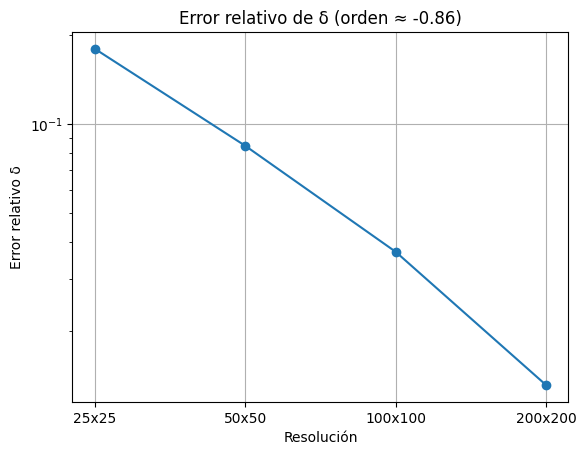

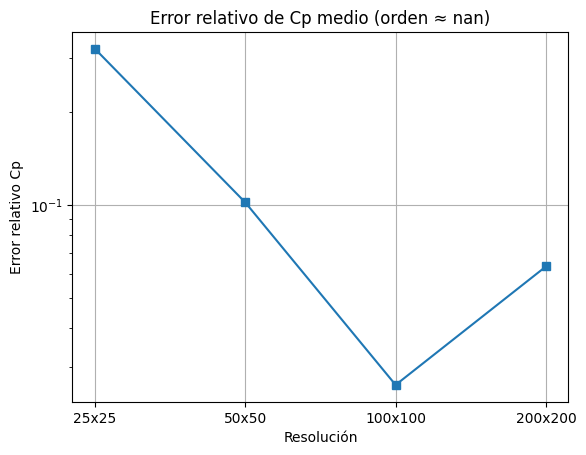

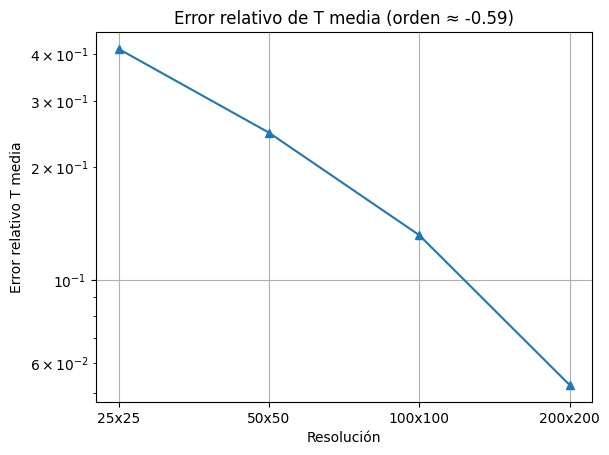

In [9]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ADAPTADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9, x_target=1.0):
    x_index = np.argmin(np.abs(X_star[0] - x_target))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)
    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return np.nan  # mejor que y[-1], pues permite detectar error

def calcular_coeficiente_presion_derecha(p, X_star):
    j = np.argmin(np.abs(X_star[-1] - 1.0))
    return np.mean(p[:, j])

def calcular_temperatura_media(T):
    return np.mean(T)

def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- GRÁFICAS ---
def representar_convergencia(res_labels, delta_vals, cp_vals, Tavg_vals):
    r = 2
    delta_ref = delta_vals[-1]
    cp_ref = cp_vals[-1]
    Tavg_ref = Tavg_vals[-1]

    delta_errs = [abs(d - delta_ref) / delta_ref for d in delta_vals[:-1]]
    cp_errs = [abs(c - cp_ref) / cp_ref for c in cp_vals[:-1]]
    Tavg_errs = [abs(t - Tavg_ref) / Tavg_ref for t in Tavg_vals[:-1]]
    labels_err = res_labels[:len(delta_errs)]

    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_cp = orden_convergencia(cp_vals[-3], cp_vals[-2], cp_vals[-1], r)
        p_T = orden_convergencia(Tavg_vals[-3], Tavg_vals[-2], Tavg_vals[-1], r)
    else:
        p_delta = p_cp = p_T = np.nan

    plt.figure()
    plt.plot(labels_err, delta_errs, marker='o')
    plt.yscale('log')
    plt.title(f'Error relativo de δ (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo δ')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, cp_errs, marker='s')
    plt.yscale('log')
    plt.title(f'Error relativo de Cp medio (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo Cp')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, Tavg_errs, marker='^')
    plt.yscale('log')
    plt.title(f'Error relativo de T media (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo T media')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800)]  # , (1600, 1600)

delta_vals, cp_vals, Tavg_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        cp = calcular_coeficiente_presion_derecha(p, X_star)
        Tavg = calcular_temperatura_media(T)

        if any(np.isnan([delta, cp, Tavg])):
            raise ValueError("Métrica no válida (NaN)")

        delta_vals.append(delta)
        cp_vals.append(cp)
        Tavg_vals.append(Tavg)
        labels.append(f"{nx}x{ny}")

        print(f"{nx}x{ny} → δ = {delta:.5f}, Cp = {cp:.5f}, Tavg = {Tavg:.5f}")

    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR RESULTADOS ---
representar_convergencia(labels, delta_vals, cp_vals, Tavg_vals)


# Convergencia con presion

25x25 → δ = 0.36384, Cp = 2.15871, Tavg = 0.03459
50x50 → δ = 0.32991, Cp = 2.86123, Tavg = 0.04281
100x100 → δ = 0.30977, Cp = 3.67893, Tavg = 0.04819
200x200 → δ = 0.29759, Cp = 4.78076, Tavg = 0.05192
400x400 → δ = 0.28937, Cp = 6.78857, Tavg = 0.05446
❌ Archivo no encontrado: sim_datos_pres/800x800.pkl


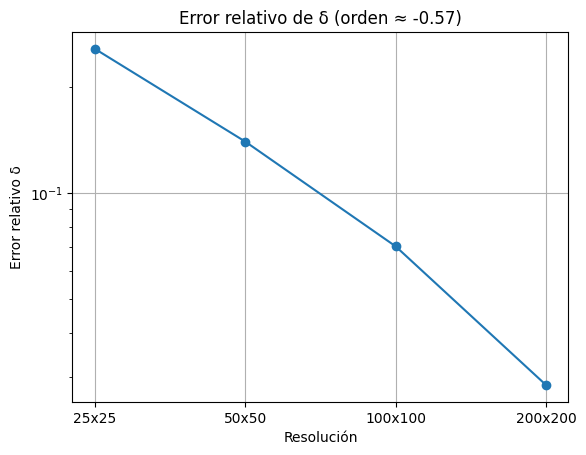

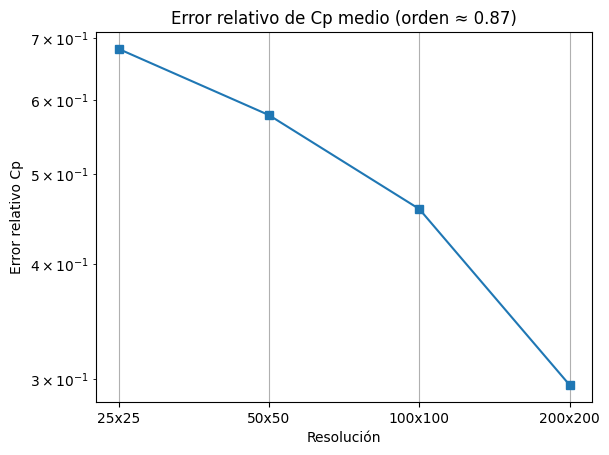

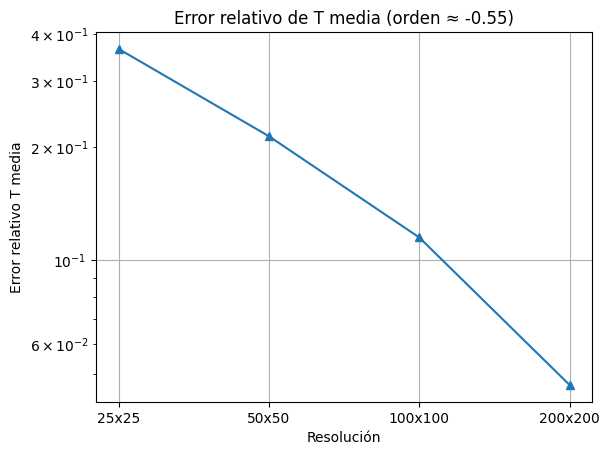

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# --- MÉTRICAS ADAPTADAS ---

def calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star, vel_level=0.9, x_target=1.0):
    x_index = np.argmin(np.abs(X_star[0] - x_target))
    y = Y_star[:, x_index]
    u_col = np.sqrt(u[:, x_index]**2 + v[:, x_index]**2)
    for i in range(len(u_col) - 1):
        if (u_col[i] < vel_level and u_col[i+1] > vel_level) or (u_col[i] > vel_level and u_col[i+1] < vel_level):
            dy = y[i+1] - y[i]
            du = u_col[i+1] - u_col[i]
            return y[i] + (vel_level - u_col[i]) * dy / du
    return np.nan  # mejor que y[-1], pues permite detectar error

def calcular_coeficiente_presion_derecha(p, X_star):
    j = np.argmin(np.abs(X_star[-1] - 1.0))
    return np.mean(p[:, j])

def calcular_temperatura_media(T):
    return np.mean(T)

def orden_convergencia(f1, f2, f3, r):
    num = f3 - f2
    den = f2 - f1
    if den == 0 or num == 0 or (num / den) <= 0:
        return np.nan
    return np.log(num / den) / np.log(r)

# --- GRÁFICAS ---
def representar_convergencia(res_labels, delta_vals, cp_vals, Tavg_vals):
    r = 2
    delta_ref = delta_vals[-1]
    cp_ref = cp_vals[-1]
    Tavg_ref = Tavg_vals[-1]

    delta_errs = [abs(d - delta_ref) / delta_ref for d in delta_vals[:-1]]
    cp_errs = [abs(c - cp_ref) / cp_ref for c in cp_vals[:-1]]
    Tavg_errs = [abs(t - Tavg_ref) / Tavg_ref for t in Tavg_vals[:-1]]
    labels_err = res_labels[:len(delta_errs)]

    if len(delta_vals) >= 3:
        p_delta = orden_convergencia(delta_vals[-3], delta_vals[-2], delta_vals[-1], r)
        p_cp = orden_convergencia(cp_vals[-3], cp_vals[-2], cp_vals[-1], r)
        p_T = orden_convergencia(Tavg_vals[-3], Tavg_vals[-2], Tavg_vals[-1], r)
    else:
        p_delta = p_cp = p_T = np.nan

    plt.figure()
    plt.plot(labels_err, delta_errs, marker='o')
    plt.yscale('log')
    plt.title(f'Error relativo de δ (orden ≈ {p_delta:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo δ')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, cp_errs, marker='s')
    plt.yscale('log')
    plt.title(f'Error relativo de Cp medio (orden ≈ {p_cp:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo Cp')
    plt.grid()

    plt.figure()
    plt.plot(labels_err, Tavg_errs, marker='^')
    plt.yscale('log')
    plt.title(f'Error relativo de T media (orden ≈ {p_T:.2f})')
    plt.xlabel('Resolución')
    plt.ylabel('Error relativo T media')
    plt.grid()

    plt.show()

# --- CARGA Y PROCESAMIENTO ---
carpeta = 'sim_datos_pres'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400), (800, 800)]  # , (1600, 1600)

delta_vals, cp_vals, Tavg_vals, labels = [], [], [], []

for nx, ny in resoluciones:
    archivo = os.path.join(carpeta, f"{nx}x{ny}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ Archivo no encontrado: {archivo}")
        continue

    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        u = sim["u_history"][-1]
        v = sim["v_history"][-1]
        p = sim["p_history"][-1]
        T = sim["T_history"][-1]
        X_star = sim["X_star"]
        Y_star = sim["Y_star"]

        delta = calcular_boundary_layer_thickness_veloc(u, v, X_star, Y_star)
        cp = calcular_coeficiente_presion_derecha(p, X_star)
        Tavg = calcular_temperatura_media(T)

        if any(np.isnan([delta, cp, Tavg])):
            raise ValueError("Métrica no válida (NaN)")

        delta_vals.append(delta)
        cp_vals.append(cp)
        Tavg_vals.append(Tavg)
        labels.append(f"{nx}x{ny}")

        print(f"{nx}x{ny} → δ = {delta:.5f}, Cp = {cp:.5f}, Tavg = {Tavg:.5f}")

    except Exception as e:
        print(f"⚠️ Error al procesar {archivo}: {e}")

# --- MOSTRAR RESULTADOS ---
representar_convergencia(labels, delta_vals, cp_vals, Tavg_vals)


# Animacion de sim sin pres

In [ ]:
import numpy as np
import os
import pickle
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.pyplot as plt

def animar_resultados_linea(sim_data, vel_level=0.9, temp_level=0.01):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    dt_star = sim_data["params"]["dt_star"]

    dt_star_visual = 1.0 / len(u_hist)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

    text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))
    text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))

    def interp_crossing(y, field, level):
        for i in range(len(field) - 1):
            f1, f2 = field[i], field[i+1]
            if (f1 < level and f2 > level) or (f1 > level and f2 < level):
                dy = y[i+1] - y[i]
                df = f2 - f1
                return y[i] + (level - f1) * dy / df
        return None

    def y_on_line_at_x(line_points, x_target):
        tol = 0.01
        x_vals, y_vals = line_points[:, 0], line_points[:, 1]
        close_idx = np.where(np.abs(x_vals - x_target) < tol)[0]
        if len(close_idx) == 0:
            return None
        return float(np.max(y_vals[close_idx]))

    linea_temp_plot, = ax2.plot([], [], 'k', linewidth=1.5)

    def update(frame):
        speed = np.sqrt(u_hist[frame]**2 + v_hist[frame]**2)

        for ax in [ax1, ax2, ax3, ax4]:
            while ax.collections:
                ax.collections[-1].remove()

        ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
        ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

        cs = ax2.contour(X_star, Y_star, T_hist[frame], levels=[temp_level], colors='k', linewidths=1.5)
        selected_line = None
        if cs.allsegs and len(cs.allsegs[0]) > 0:
            selected_line = np.concatenate(cs.allsegs[0])
            linea_temp_plot.set_data(selected_line[:, 0], selected_line[:, 1])
        else:
            linea_temp_plot.set_data([], [])

        ax2.contourf(X_star, Y_star, T_hist[frame], levels=20, cmap='jet')
        ax3.contourf(X_star, Y_star, p_hist[frame], levels=20, cmap='viridis')
        ax4.contourf(X_star, Y_star, tau_hist[frame], levels=20, cmap='coolwarm')

        t_star = frame * dt_star_visual
        ax1.set_title(f'Velocidad |u*| (t*={t_star:.2f})')
        ax2.set_title(f'Temperatura T* (t*={t_star:.2f})')
        ax3.set_title(f'Presi\u00f3n p* (t*={t_star:.2f})')
        ax4.set_title(f'Shear stress \u03c4* (t*={t_star:.2f})')

        y80 = y_on_line_at_x(selected_line, 0.80) if selected_line is not None else None
        y95 = y_on_line_at_x(selected_line, 0.95) if selected_line is not None else None

        y80_str = f"{y80:.4f}" if y80 is not None else "No definido"
        y95_str = f"{y95:.4f}" if y95 is not None else "No definido"
        text2.set_text(f'L\u00ednea T* en x=0.80: {y80_str}\nL\u00ednea T* en x=0.95: {y95_str}')

        x_index = np.argmin(np.abs(X_star[0] - 1.0))
        y_col = Y_star[:, x_index]
        u_col = np.sqrt(u_hist[frame][:, x_index]**2 + v_hist[frame][:, x_index]**2)
        y_vel = interp_crossing(y_col, u_col, vel_level)
        y_vel_str = f"{y_vel:.4f}" if y_vel is not None else "No definido"
        text1.set_text(f'y* @ x=1 donde |u*|={vel_level}:\n{y_vel_str}')

        if frame == len(u_hist) - 1:
            print(f"\nt* = {t_star:.3f}")
            print(f"  |u*|={vel_level} @ x=1 \u2192 y* = {y_vel_str}")
            print(f"  L\u00ednea T* @ x=0.80 \u2192 y* = {y80_str}")
            print(f"  L\u00ednea T* @ x=0.95 \u2192 y* = {y95_str}")

        return ax1.collections + ax2.collections + ax3.collections + ax4.collections + [text1, text2, linea_temp_plot]

    # Primer fotograma con barras de color
    speed = np.sqrt(u_hist[0]**2 + v_hist[0]**2)

    cs1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)
    plt.colorbar(cs1, ax=ax1, orientation='vertical', label='|u*|')

    cs2 = ax2.contourf(X_star, Y_star, T_hist[0], levels=20, cmap='jet')
    cs0 = ax2.contour(X_star, Y_star, T_hist[0], levels=[temp_level], colors='k', linewidths=1.5)
    if cs0.allsegs and len(cs0.allsegs[0]) > 0:
        selected_line0 = np.concatenate(cs0.allsegs[0])
        linea_temp_plot.set_data(selected_line0[:, 0], selected_line0[:, 1])
    else:
        linea_temp_plot.set_data([], [])
    plt.colorbar(cs2, ax=ax2, orientation='vertical', label='T*')

    cs3 = ax3.contourf(X_star, Y_star, p_hist[0], levels=20, cmap='viridis')
    plt.colorbar(cs3, ax=ax3, orientation='vertical', label='p*')

    cs4 = ax4.contourf(X_star, Y_star, tau_hist[0], levels=20, cmap='coolwarm')
    plt.colorbar(cs4, ax=ax4, orientation='vertical', label='\u03c4*')

    fig.suptitle(f"Simulaci\u00f3n con resoluci\u00f3n {X_star.shape[1]}x{Y_star.shape[0]}, CFL fija", fontsize=14)
    plt.tight_layout()

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


# Asegurar carpeta de salida
output_folder = 'opti_anim'
os.makedirs(output_folder, exist_ok=True)

# --- Procesar archivos ---
carpeta = 'sim_datos'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400)]
#resoluciones = [(800, 800), (1600, 1600)]

for nx, ny in resoluciones:
    nombre = f"{nx}x{ny}"
    archivo = os.path.join(carpeta, f"{nombre}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ No se encontró: {archivo}")
        continue

    print(f"🎞️ Generando animación para {nombre}...")
    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        anim, fig = animar_resultados_linea(sim)
        salida_mp4 = os.path.join(output_folder, f"{nombre}.mp4")

        writer = FFMpegWriter(fps=10, metadata={"title": nombre})
        anim.save(salida_mp4, writer=writer)
        plt.close(fig)
        print(f"✅ Guardado: {salida_mp4}")
    except Exception as e:
        print(f"⚠️ Error al animar {nombre}: {e}")


🎞️ Generando animación para 25x25...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim/25x25.mp4
🎞️ Generando animación para 50x50...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim/50x50.mp4
🎞️ Generando animación para 100x100...
⚠️ Error al animar 100x100: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x800', '-pix_fmt', 'rgba', '-framerate', '10', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-metadata', 'title=100x100', '-y', 'opti_anim/100x100.mp4']' returned non-zero exit status 255.
🎞️ Generando animación para 200x200...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = 0.2749
  Línea T* @ x=0.80 → y* = 0.5029
  Línea T* @ x=0.95 → y* = 0.5087
✅ Guardado: opti_anim/200x200.mp4
🎞️ Generando animación para 400x400...


# Animacion con presion

In [4]:
import numpy as np
import os
import pickle
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.pyplot as plt

def animar_resultados_linea(sim_data, vel_level=0.9, temp_level=0.01):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    dt_star = sim_data["params"]["dt_star"]

    dt_star_visual = 1.0 / len(u_hist)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

    text1 = ax1.text(0.02, 0.95, '', transform=ax1.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))
    text2 = ax2.text(0.02, 0.95, '', transform=ax2.transAxes, fontsize=9, color='white',
                     bbox=dict(facecolor='black', alpha=0.5))

    def interp_crossing(y, field, level):
        for i in range(len(field) - 1):
            f1, f2 = field[i], field[i+1]
            if (f1 < level and f2 > level) or (f1 > level and f2 < level):
                dy = y[i+1] - y[i]
                df = f2 - f1
                return y[i] + (level - f1) * dy / df
        return None

    def y_on_line_at_x(line_points, x_target):
        tol = 0.01
        x_vals, y_vals = line_points[:, 0], line_points[:, 1]
        close_idx = np.where(np.abs(x_vals - x_target) < tol)[0]
        if len(close_idx) == 0:
            return None
        return float(np.max(y_vals[close_idx]))

    linea_temp_plot, = ax2.plot([], [], 'k', linewidth=1.5)

    def update(frame):
        speed = np.sqrt(u_hist[frame]**2 + v_hist[frame]**2)

        for ax in [ax1, ax2, ax3, ax4]:
            while ax.collections:
                ax.collections[-1].remove()

        ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
        ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)

        cs = ax2.contour(X_star, Y_star, T_hist[frame], levels=[temp_level], colors='k', linewidths=1.5)
        selected_line = None
        if cs.allsegs and len(cs.allsegs[0]) > 0:
            selected_line = np.concatenate(cs.allsegs[0])
            linea_temp_plot.set_data(selected_line[:, 0], selected_line[:, 1])
        else:
            linea_temp_plot.set_data([], [])

        ax2.contourf(X_star, Y_star, T_hist[frame], levels=20, cmap='jet')
        ax3.contourf(X_star, Y_star, p_hist[frame], levels=20, cmap='viridis')
        ax4.contourf(X_star, Y_star, tau_hist[frame], levels=20, cmap='coolwarm')

        t_star = frame * dt_star_visual
        ax1.set_title(f'Velocidad |u*| (t*={t_star:.2f})')
        ax2.set_title(f'Temperatura T* (t*={t_star:.2f})')
        ax3.set_title(f'Presi\u00f3n p* (t*={t_star:.2f})')
        ax4.set_title(f'Shear stress \u03c4* (t*={t_star:.2f})')

        y80 = y_on_line_at_x(selected_line, 0.80) if selected_line is not None else None
        y95 = y_on_line_at_x(selected_line, 0.95) if selected_line is not None else None

        y80_str = f"{y80:.4f}" if y80 is not None else "No definido"
        y95_str = f"{y95:.4f}" if y95 is not None else "No definido"
        text2.set_text(f'L\u00ednea T* en x=0.80: {y80_str}\nL\u00ednea T* en x=0.95: {y95_str}')

        x_index = np.argmin(np.abs(X_star[0] - 1.0))
        y_col = Y_star[:, x_index]
        u_col = np.sqrt(u_hist[frame][:, x_index]**2 + v_hist[frame][:, x_index]**2)
        y_vel = interp_crossing(y_col, u_col, vel_level)
        y_vel_str = f"{y_vel:.4f}" if y_vel is not None else "No definido"
        text1.set_text(f'y* @ x=1 donde |u*|={vel_level}:\n{y_vel_str}')

        if frame == len(u_hist) - 1:
            print(f"\nt* = {t_star:.3f}")
            print(f"  |u*|={vel_level} @ x=1 \u2192 y* = {y_vel_str}")
            print(f"  L\u00ednea T* @ x=0.80 \u2192 y* = {y80_str}")
            print(f"  L\u00ednea T* @ x=0.95 \u2192 y* = {y95_str}")

        return ax1.collections + ax2.collections + ax3.collections + ax4.collections + [text1, text2, linea_temp_plot]

    # Primer fotograma con barras de color
    speed = np.sqrt(u_hist[0]**2 + v_hist[0]**2)

    cs1 = ax1.contourf(X_star, Y_star, speed, levels=20, cmap='jet')
    ax1.contour(X_star, Y_star, speed, levels=[vel_level], colors='k', linewidths=1.5)
    plt.colorbar(cs1, ax=ax1, orientation='vertical', label='|u*|')

    cs2 = ax2.contourf(X_star, Y_star, T_hist[0], levels=20, cmap='jet')
    cs0 = ax2.contour(X_star, Y_star, T_hist[0], levels=[temp_level], colors='k', linewidths=1.5)
    if cs0.allsegs and len(cs0.allsegs[0]) > 0:
        selected_line0 = np.concatenate(cs0.allsegs[0])
        linea_temp_plot.set_data(selected_line0[:, 0], selected_line0[:, 1])
    else:
        linea_temp_plot.set_data([], [])
    plt.colorbar(cs2, ax=ax2, orientation='vertical', label='T*')

    cs3 = ax3.contourf(X_star, Y_star, p_hist[0], levels=20, cmap='viridis')
    plt.colorbar(cs3, ax=ax3, orientation='vertical', label='p*')

    cs4 = ax4.contourf(X_star, Y_star, tau_hist[0], levels=20, cmap='coolwarm')
    plt.colorbar(cs4, ax=ax4, orientation='vertical', label='\u03c4*')

    fig.suptitle(f"Simulaci\u00f3n con resoluci\u00f3n {X_star.shape[1]}x{Y_star.shape[0]}, CFL fija", fontsize=14)
    plt.tight_layout()

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


# Asegurar carpeta de salida
output_folder = 'opti_anim_pres'
os.makedirs(output_folder, exist_ok=True)

# --- Procesar archivos ---
carpeta = 'sim_datos_pres'
resoluciones = [(25, 25), (50, 50), (100, 100), (200, 200), (400, 400)]
#resoluciones = [(800, 800), (1600, 1600)]

for nx, ny in resoluciones:
    nombre = f"{nx}x{ny}"
    archivo = os.path.join(carpeta, f"{nombre}.pkl")
    if not os.path.exists(archivo):
        print(f"❌ No se encontró: {archivo}")
        continue

    print(f"🎞️ Generando animación para {nombre}...")
    with open(archivo, 'rb') as f:
        sim = pickle.load(f)

    try:
        anim, fig = animar_resultados_linea(sim)
        salida_mp4 = os.path.join(output_folder, f"{nombre}.mp4")

        writer = FFMpegWriter(fps=10, metadata={"title": nombre})
        anim.save(salida_mp4, writer=writer)
        plt.close(fig)
        print(f"✅ Guardado: {salida_mp4}")
    except Exception as e:
        print(f"⚠️ Error al animar {nombre}: {e}")


🎞️ Generando animación para 25x25...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim_pres/25x25.mp4
🎞️ Generando animación para 50x50...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim_pres/50x50.mp4
🎞️ Generando animación para 100x100...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim_pres/100x100.mp4
🎞️ Generando animación para 200x200...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim_pres/200x200.mp4
🎞️ Generando animación para 400x400...

t* = 0.997
  |u*|=0.9 @ x=1 → y* = No definido
  Línea T* @ x=0.80 → y* = No definido
  Línea T* @ x=0.95 → y* = No definido
✅ Guardado: opti_anim_pres/